# CX 프로젝트 — 전처리 & 클러스터링 (Actor 도출)
### 주제: "무관심한 내 일상을 깨우는 가전 구독"

**이 노트북의 흐름**
> raw 데이터 → 전처리 → 형태소 분리(MeCab) → **임베딩(Sentence-Transformers)** → HDBSCAN 노이즈 제거 → KMeans 클러스터링 → C-TF-IDF 해석 → Actor 도출

**변경점**: 벡터화를 TF-IDF 대신 **한국어 사전학습 임베딩 모델**로 교체
- TF-IDF: 단어 빈도 기반 → "렌탈이 부담스럽다"와 "구독료가 비싸다"를 다른 문서로 인식
- Sentence-Transformers: 의미 기반 → 단어가 달라도 뜻이 비슷하면 가까운 벡터

---

## 0. 환경 설정 (Colab)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 작업 디렉토리 설정 (본인 경로로 변경)
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/CX 프로젝트/새 폴더
!pwd

# import os
# os.makedirs('./data', exist_ok=True)

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/CX 프로젝트/새 폴더
/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/CX 프로젝트/새 폴더


In [3]:
# 라이브러리 설치
!pip install python-mecab-ko --quiet
!pip install sentence-transformers --quiet
!pip install hdbscan umap-learn --quiet
!pip install gensim pyLDAvis scikit-learn matplotlib seaborn wordcloud tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 84.8 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# 형태소 분석
import mecab
mecab_tagger = mecab.MeCab()

# 임베딩
from sentence_transformers import SentenceTransformer

# 클러스터링 & 평가
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer
import hdbscan
import umap

# 시각화
import matplotlib.pyplot as plt
import matplotlib
# matplotlib.rcParams['font.family'] = 'NanumGothic'
# matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [5]:
!ls

 00파일병합.ipynb
'01_actor 도출 실습.ipynb'
 02전처리.ipynb
'02_카카오톡 데이터 실습 copy.ipynb'
'02_카카오톡 데이터 실습.ipynb'
 03_기획영역분석실습.ipynb
 actor_topic_selection.png
 ccooddee
 cluster_metrics.png
 cluster_review.csv
 cluster_review_fm.pkl
 cluster_review.pkl
 cluster_scatter.png
 cluster_군집0.csv
 cluster_군집0_fm제외.csv
 cluster_군집1.csv
 cluster_군집1_fm제외.csv
 cluster_군집2.csv
 cluster_군집2_fm제외.csv
 cluster_군집3.csv
 cluster_군집4.csv
 csv별_상위단어.csv
 csv별_상위단어_통합버전.csv
 CX_01_actor_embedding.ipynb
'CX_01_actor_preprocessing_fm최신순,키워드추가제외 ver.ipynb'
'CX_01_actor_preprocessing_데이터 전체 통합 ver.ipynb'
 CX_01_actor_tfidf.ipynb
 CX_preprocessing_clustering.ipynb
 data
 data_preprocessing.py
 dendrogram.png
 dov2vec기반
 embeddings.npy
 embedding기반
 fm최신순.csv
 fm최신순_키워드추가.csv
 hdbscan_umap.png
 ko-stopwords.csv
 ldavis_actor0_action.html
 ldavis_actor1_action.html

## 1. 데이터 로딩

In [6]:
# ============================
FILE_PATH = "./merged_raw_except_fm.csv"
# ============================

df = pd.read_csv(FILE_PATH)
print(f"원본 데이터: {len(df):,}건")
print(f"컬럼: {list(df.columns)}")
df.head()

원본 데이터: 13,465건
컬럼: ['title', 'content', 'source_file']


,title,content,source_file
0,NaN,"제가 쿠쿠정수기 렌탈을 약 6년전에 시작해서 매달 19,900원을 내고 5년 사용후...","네이트판_통합_렌탈,가전구독.csv"
1,NaN,정수기 설치 알아보다 웅진 코웨이로 정하고 대리점에서 하려하니 지인이 당근 렌탈업체...,"네이트판_통합_렌탈,가전구독.csv"
2,NaN,오늘 이걸로 남사친이랑 엄청 싸웠습니다. 요즘 “커피 심부름은 60~70년대 얘기고...,"네이트판_통합_렌탈,가전구독.csv"
3,NaN,저는 지금 사진을 즐겨 취미로 하고있는 대학생입니다. 정말 애정을 가지고 하는 취미...,"네이트판_통합_렌탈,가전구독.csv"
4,NaN,무엇이든 렌탈을 하기전에 구체적인 계약내용을 친필로 적어 두는 것이 좋습니다. 일...,"네이트판_통합_렌탈,가전구독.csv"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13465 entries, 0 to 13464
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        10045 non-null  object
 1   content      13397 non-null  object
 2   source_file  13465 non-null  object
dtypes: object(3)
memory usage: 315.7+ KB


## 2. 데이터 전처리
### 2.1 특수문자 제거

In [8]:
import re

pattern = r'[^a-zA-Z0-9가-힣\s]'

df['content_clean'] = [re.sub(pattern, " ", str(review)) for review in df['content']]
df['content_clean'] = df['content_clean'].apply(lambda x: re.sub(r'https?\S+', '', x))
df['content_clean'] = df['content_clean'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

df[['content', 'content_clean']].head()

,content,content_clean
0,"제가 쿠쿠정수기 렌탈을 약 6년전에 시작해서 매달 19,900원을 내고 5년 사용후...",제가 쿠쿠정수기 렌탈을 약 6년전에 시작해서 매달 19 900원을 내고 5년 사용후...
1,정수기 설치 알아보다 웅진 코웨이로 정하고 대리점에서 하려하니 지인이 당근 렌탈업체...,정수기 설치 알아보다 웅진 코웨이로 정하고 대리점에서 하려하니 지인이 당근 렌탈업체...
2,오늘 이걸로 남사친이랑 엄청 싸웠습니다. 요즘 “커피 심부름은 60~70년대 얘기고...,오늘 이걸로 남사친이랑 엄청 싸웠습니다 요즘 커피 심부름은 60 70년대 얘기고 8...
3,저는 지금 사진을 즐겨 취미로 하고있는 대학생입니다. 정말 애정을 가지고 하는 취미...,저는 지금 사진을 즐겨 취미로 하고있는 대학생입니다 정말 애정을 가지고 하는 취미인...
4,무엇이든 렌탈을 하기전에 구체적인 계약내용을 친필로 적어 두는 것이 좋습니다. 일...,무엇이든 렌탈을 하기전에 구체적인 계약내용을 친필로 적어 두는 것이 좋습니다 일단 ...


### 2.2 의미없는 짧은 글 제거

In [9]:
before = len(df)

drop_index = []
for i, review in enumerate(df['content_clean']):
    if len(str(review)) < 10:
        drop_index.append(i)

if len(drop_index) > 0:
    df.drop(drop_index, inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"10자 미만 제거: {before:,} -> {len(df):,}건")

10자 미만 제거: 13,465 -> 13,160건


### 2.3 결측값 & 중복 제거

In [10]:
before = len(df)

df = df.dropna(subset=['content_clean'])
df = df.drop_duplicates(subset=['content_clean'], keep='first')
df.reset_index(drop=True, inplace=True)

print(f"결측/중복 제거: {before:,} -> {len(df):,}건")

결측/중복 제거: 13,160 -> 12,414건


### 2.4 광고/홍보 + 노이즈 필터링

In [11]:
ad_keywords = [
    '광고', '협찬', '홍보', '체험단', '원고료', '소정의', '제공받',
    '무료체험', '서포터즈', '앰배서더', '파트너스',
    '최저가', '특가', '할인코드', '쿠폰코드', '프로모션코드',
    '링크타고', '링크클릭', '구매링크', '제휴링크',
    '카톡문의', '카카오톡문의', 'DM문의', '문의주세요',
    '선착순', '한정수량', '마감임박',
    '설치문의', '무료설치', '사은품증정', '렌탈프로모션',
    '업체추천', '파격할인', '이벤트진행중','사은품','원고료',
    '본 포스팅은', '업체로부터', '제품을 제공', '원고료를 지급',
    '대가를 받고', '경제적 대가',
]

noise_keywords = [
    '반등', '매수', '매도', '매매', '투자', '거래대금', '주식', '환율', '소액결제',
    '루팅', '루트', '펌웨어', '커스텀롬', '커스텀', '부팅', '초기화', '벽돌',
    '리커버리', '일련번호', '유틸', '카운터','유튜브','정치','youtube','Youtube','유튭',
    'skt', 'kt', 'u\+', '통신사', '지원금',
    '화장품', '피부', '두피', '액상',
    '스마트싱스', 'SmartThings', '스마트씽', '빅스비', 'smart things', '스마트 싱스',
    '스마트스토어', '쿠팡', '수수료', '재택', '부업', '수익',
    '특가', '최저가', '역대급', '찬스', '사은품', '당일지급', '핫딜', '세일',
    '파트너스', '공동구매',
]

remove_keywords = ad_keywords + noise_keywords

before = len(df)
combined = df['content_clean'].fillna('') + ' ' + df['title'].fillna('')
remove_mask = combined.str.contains('|'.join(remove_keywords), case=False, na=False)

df_removed = df[remove_mask].copy()
df = df[~remove_mask].copy()
df.reset_index(drop=True, inplace=True)

df_removed.to_csv("./removed_data.csv", index=False, encoding='utf-8-sig')
print(f"광고+노이즈 제거: {before - len(df):,}건 제거 -> {len(df):,}건 남음")

광고+노이즈 제거: 4,300건 제거 -> 8,114건 남음


## 3. 형태소 분리 (MeCab)

> 임베딩 모델은 원문으로 벡터화하지만,
> **C-TF-IDF 해석 단계에서 형태소 분석 결과가 필요**하므로 여기서 미리 수행합니다.

In [12]:
# 불용어 파일이 있는 경우 (ko-stopwords.csv)
stopwords = pd.read_csv("./ko-stopwords.csv")
stopwords_list = list(stopwords['stopwords'])

print(f"불용어 수: {len(stopwords_list)}개")

def pos_tagging(text):
    pos_words = mecab_tagger.pos(str(text))
    result = []
    for token, tag in pos_words:
        if tag in ['NNG', 'NNP', 'VV', 'VA']:
            if len(token) >= 2 and token not in stopwords_list:
                result.append(token)
    return result

# 테스트
sample_txt = "정수기 렌탈 3년 약정인데 위약금이 얼마나 되나요"
print("원문:", sample_txt)
print("토큰:", pos_tagging(sample_txt))

불용어 수: 599개
원문: 정수기 렌탈 3년 약정인데 위약금이 얼마나 되나요
토큰: ['정수기', '렌탈', '약정', '위약금']


In [13]:
from tqdm import tqdm
tqdm.pandas()

print(f"{len(df):,}건 토큰화 시작...")
df['tagged_review'] = df['content_clean'].progress_apply(pos_tagging)

# 빈 토큰 행 제거
before = len(df)
df = df[df['tagged_review'].apply(len) > 0]
df.reset_index(drop=True, inplace=True)
print(f"빈 토큰 제거: {before:,} -> {len(df):,}건")

8,114건 토큰화 시작...


100%|██████████| 8114/8114 [00:28<00:00, 286.24it/s]

빈 토큰 제거: 8,114 -> 8,017건


In [14]:
df.to_pickle('./embedding_tagged_review.pkl')
print(f"embedding_tagged_review.pkl 저장 완료 ({len(df):,}건)")

embedding_tagged_review.pkl 저장 완료 (8,017건)


## 4. 임베딩 (Sentence-Transformers)

TF-IDF 대신 **한국어 사전학습 임베딩 모델**을 사용합니다.
- 모델: `jhgan/ko-sroberta-multitask` (한국어 특화, 768차원)
- **원문 텍스트를 그대로 입력** → 의미 기반 벡터 생성
- "렌탈이 부담스럽다" ≈ "구독료가 비싸다" → 가까운 벡터로 변환

> Colab GPU(T4) 기준 약 10~20분 소요됩니다.
> 런타임 > 런타임 유형 변경 > GPU(T4) 선택을 확인하세요.

In [15]:
df = pd.read_pickle('./embedding_tagged_review.pkl')
df

,title,content,source_file,content_clean,tagged_review
0,NaN,"제가 쿠쿠정수기 렌탈을 약 6년전에 시작해서 매달 19,900원을 내고 5년 사용후...","네이트판_통합_렌탈,가전구독.csv",제가 쿠쿠정수기 렌탈을 약 6년전에 시작해서 매달 19 900원을 내고 5년 사용후...,"[쿠쿠, 정수기, 렌탈, 시작, 사용, 개인, 소유, 변경, 멤버, 서비스, 필터,..."
1,NaN,오늘 이걸로 남사친이랑 엄청 싸웠습니다. 요즘 “커피 심부름은 60~70년대 얘기고...,"네이트판_통합_렌탈,가전구독.csv",오늘 이걸로 남사친이랑 엄청 싸웠습니다 요즘 커피 심부름은 60 70년대 얘기고 8...,"[사친, 커피, 심부름, 얘기, 대생, 보이, 현실, 왜곡, 본인, 기억, 편하, ..."
2,NaN,무엇이든 렌탈을 하기전에 구체적인 계약내용을 친필로 적어 두는 것이 좋습니다. 일...,"네이트판_통합_렌탈,가전구독.csv",무엇이든 렌탈을 하기전에 구체적인 계약내용을 친필로 적어 두는 것이 좋습니다 일단 ...,"[렌탈, 구체, 계약, 내용, 친필, 계약, 무기, 간전, 해약, 경우, 비용, 지..."
3,NaN,제목대로 어떻게 해야할까요?? 믿어야할까요? 남친 26이고 저는 23입니다. 사귄지...,"네이트판_통합_렌탈,가전구독.csv",제목대로 어떻게 해야할까요 믿어야할까요 남친 26이고 저는 23입니다 사귄지는 2년...,"[제목, 남친, 죄목, 미성년자, 유사, 강간, 남친, 문서, 마시, 여자, 성인,..."
4,NaN,안녕하세요~ 맨날 눈톡질만하다가 처음으로 글쓰기를 눌러본 91년생을 동경하는 92년...,"네이트판_통합_렌탈,가전구독.csv",안녕하세요 맨날 눈톡질만하다가 처음으로 글쓰기를 눌러본 91년생을 동경하는 92년생...,"[안녕, 처음, 글쓰기, 동경, 남자, 올해, 예체능, 핑계, 겨울, 방학, 보충,..."
...,...,...,...,...,...
8012,생활패턴,30억 예산 투입...여성들에게 생리대 '공짜' 지급,naver_news_생활루틴패턴_최종데이터.csv,30억 예산 투입 여성들에게 생리대 공짜 지급,"[예산, 투입, 여성, 생리대, 공짜, 지급]"
8013,생활패턴,"“생리대 무상 제공이 가능해?”…성평등부, 공공생리대 시범사업 추진",naver_news_생활루틴패턴_최종데이터.csv,생리대 무상 제공이 가능해 성평등부 공공생리대 시범사업 추진,"[생리대, 무상, 제공, 가능, 평등, 공공, 생리대, 시범, 사업, 추진]"
8014,생활패턴,“자판기서 ‘무료 생리대’ 뽑아 써요”…사각지대 없앤다(종합),naver_news_생활루틴패턴_최종데이터.csv,자판기서 무료 생리대 뽑아 써요 사각지대 없앤다 종합,"[자판기, 무료, 생리대, 사각지대, 종합]"
8015,생활패턴,"성평등가족부 ""모든 여성에 생리대 무상지원"" 시범사업",naver_news_생활루틴패턴_최종데이터.csv,성평등가족부 모든 여성에 생리대 무상지원 시범사업,"[평등, 가족, 여성, 생리대, 무상, 지원, 시범, 사업]"


In [16]:
# GPU 확인
!nvidia-smi | head -5

import torch
print(f"GPU 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")

Sat Mar 21 06:15:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
GPU 사용 가능: True
GPU 이름: Tesla T4


In [17]:
# 한국어 임베딩 모델 로드
print("모델 로딩 중...")
embed_model = SentenceTransformer('jhgan/ko-sroberta-multitask')

# GPU로 이동 (가능한 경우)
if torch.cuda.is_available():
    embed_model = embed_model.to(torch.device('cuda'))

print(f"모델 로드 완료: jhgan/ko-sroberta-multitask")
print(f"임베딩 차원: {embed_model.get_sentence_embedding_dimension()}")

모델 로딩 중...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

모델 로드 완료: jhgan/ko-sroberta-multitask
임베딩 차원: 768


In [18]:
# 전체 데이터 임베딩 (원문 텍스트 사용)
texts = df['content_clean'].tolist()

print(f"{len(texts):,}건 임베딩 시작... (GPU 기준 10~20분)")
embeddings = embed_model.encode(
    texts,
    show_progress_bar=True,
    batch_size=64,          # GPU 메모리에 따라 32~128 조절
    normalize_embeddings=True,  # 코사인 유사도 계산에 유리
)

print(f"\n임베딩 완료: {embeddings.shape}")
print(f"  문서 수: {embeddings.shape[0]:,}")
print(f"  벡터 차원: {embeddings.shape[1]}")

8,017건 임베딩 시작... (GPU 기준 10~20분)


Batches:   0%|          | 0/126 [00:00<?, ?it/s]


임베딩 완료: (8017, 768)
  문서 수: 8,017
  벡터 차원: 768


In [ ]:
# 임베딩 결과 저장 (시간이 오래 걸리므로 중간 저장)
np.save('./embeddings.npy', embeddings)
print("embeddings.npy 저장 완료")

# 이어서 작업할 때 로딩
# embeddings = np.load('./data/embeddings.npy')

embeddings.npy 저장 완료


## 5. 클러스터링 & 성능 지표

### 5.1 HDBSCAN으로 노이즈 제거

UMAP 차원 축소 후 HDBSCAN으로 노이즈(밀도가 낮은 데이터)를 식별하여 제거합니다.

In [19]:
# UMAP 차원 축소
print("UMAP 차원 축소 중... (2~5분 소요)")
reducer = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
)
embedding_umap = reducer.fit_transform(embeddings)
print(f"UMAP 완료: {embeddings.shape} -> {embedding_umap.shape}")

UMAP 차원 축소 중... (2~5분 소요)
UMAP 완료: (8017, 768) -> (8017, 5)


In [20]:
# HDBSCAN 실행
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
)
hdb_labels = clusterer.fit_predict(embedding_umap)

n_noise = (hdb_labels == -1).sum()
print(f"HDBSCAN 결과:")
print(f"  군집 수: {len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)}개")
print(f"  노이즈: {n_noise:,}건 ({n_noise/len(hdb_labels)*100:.1f}%)")
print(f"  유효 데이터: {(hdb_labels != -1).sum():,}건")

HDBSCAN 결과:
  군집 수: 21개
  노이즈: 1,187건 (14.8%)
  유효 데이터: 6,830건


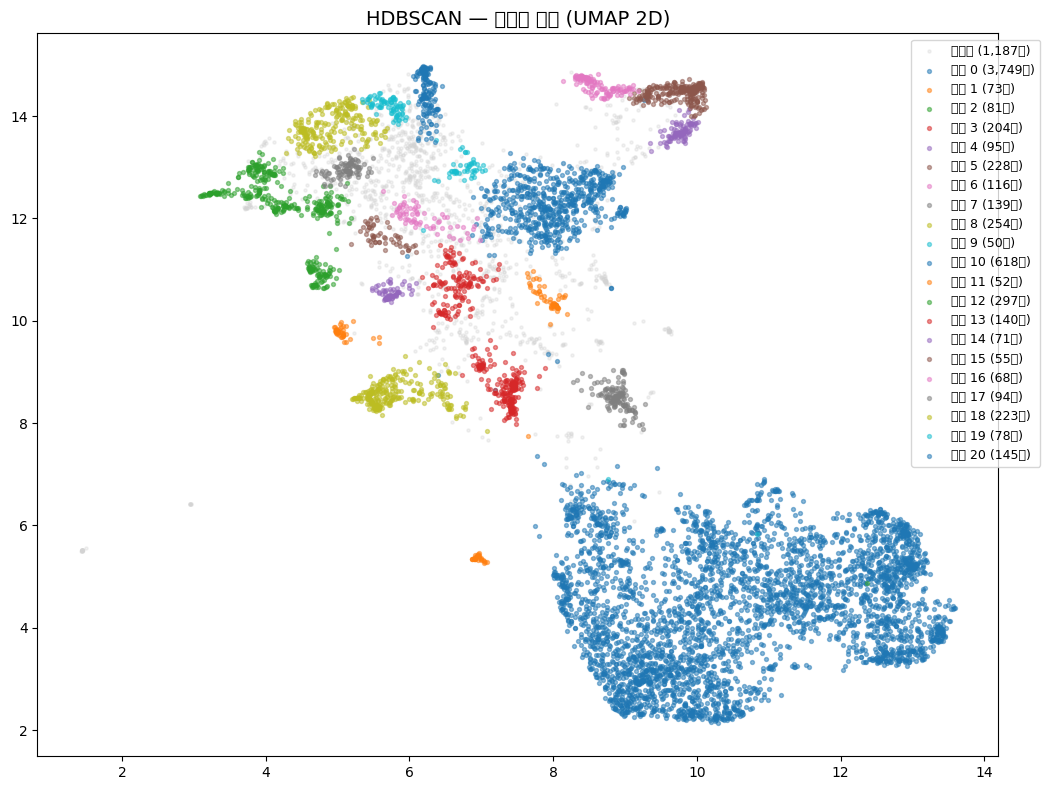

회색 = 노이즈 → 제거 후 KMeans 재클러스터링


In [21]:
# UMAP 2D 시각화 (노이즈 확인)
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reducer_2d.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))

noise_mask = hdb_labels == -1
ax.scatter(embedding_2d[noise_mask, 0], embedding_2d[noise_mask, 1],
           c='lightgray', alpha=0.3, s=5, label=f'노이즈 ({noise_mask.sum():,}건)')

for label in sorted(set(hdb_labels)):
    if label == -1:
        continue
    mask = hdb_labels == label
    ax.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
               alpha=0.5, s=8, label=f'군집 {label} ({mask.sum():,}건)')

ax.set_title('HDBSCAN — 노이즈 식별 (UMAP 2D)', fontsize=14)
ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("./hdbscan_umap.png", dpi=150, bbox_inches='tight')
plt.show()

print("회색 = 노이즈 → 제거 후 KMeans 재클러스터링")

In [23]:
# 노이즈 제거
noise_indices = np.where(hdb_labels == -1)[0]

df_clean = df.drop(index=noise_indices).reset_index(drop=True)
embeddings_clean = np.delete(embeddings, noise_indices, axis=0)
embedding_2d_clean = np.delete(embedding_2d, noise_indices, axis=0)

print(f"노이즈 제거: {len(df):,} -> {len(df_clean):,}건 ({len(noise_indices):,}건 제거)")

노이즈 제거: 8,017 -> 6,830건 (1,187건 제거)


### 5.2 최적 K 판단 — Silhouette + Davies-Bouldin + Calinski-Harabasz

| 지표 | 기준 | 해석 |
|------|------|------|
| **Silhouette** | 높을수록 좋음 (최대 1) | 피크 값에서 K 결정 |
| **Davies-Bouldin** | 낮을수록 좋음 (최소 0) | 낮고 안정적인 구간 |
| **Calinski-Harabasz** | 높을수록 좋음 | 군집 간 분산 / 군집 내 분산 비율 |

In [24]:
K_range = range(2, 11)
silhouettes = []
davies_bouldin = []
calinski = []

print("K=2~10 클러스터링 평가 중...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(embeddings_clean)

    sil = silhouette_score(embeddings_clean, labels,
                           sample_size=min(5000, len(embeddings_clean)), random_state=42)
    db = davies_bouldin_score(embeddings_clean, labels)
    ch = calinski_harabasz_score(embeddings_clean, labels)

    silhouettes.append(sil)
    davies_bouldin.append(db)
    calinski.append(ch)
    print(f"  K={k}: Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}, Calinski-Harabasz={ch:.0f}")

best_k_sil = list(K_range)[np.argmax(silhouettes)]
best_k_db = list(K_range)[np.argmin(davies_bouldin)]
best_k_ch = list(K_range)[np.argmax(calinski)]

print(f"\nSilhouette 기준 최적 K = {best_k_sil}")
print(f"Davies-Bouldin 기준 최적 K = {best_k_db}")
print(f"Calinski-Harabasz 기준 최적 K = {best_k_ch}")

K=2~10 클러스터링 평가 중...
  K=2: Silhouette=0.1091, Davies-Bouldin=2.6933, Calinski-Harabasz=870
  K=3: Silhouette=0.0937, Davies-Bouldin=3.4077, Calinski-Harabasz=592
  K=4: Silhouette=0.0918, Davies-Bouldin=3.4800, Calinski-Harabasz=480
  K=5: Silhouette=0.0540, Davies-Bouldin=3.3128, Calinski-Harabasz=411
  K=6: Silhouette=0.0594, Davies-Bouldin=3.4892, Calinski-Harabasz=363
  K=7: Silhouette=0.0556, Davies-Bouldin=3.5664, Calinski-Harabasz=324
  K=8: Silhouette=0.0509, Davies-Bouldin=3.6005, Calinski-Harabasz=295
  K=9: Silhouette=0.0507, Davies-Bouldin=3.6404, Calinski-Harabasz=271
  K=10: Silhouette=0.0490, Davies-Bouldin=3.4629, Calinski-Harabasz=254

Silhouette 기준 최적 K = 2
Davies-Bouldin 기준 최적 K = 2
Calinski-Harabasz 기준 최적 K = 2


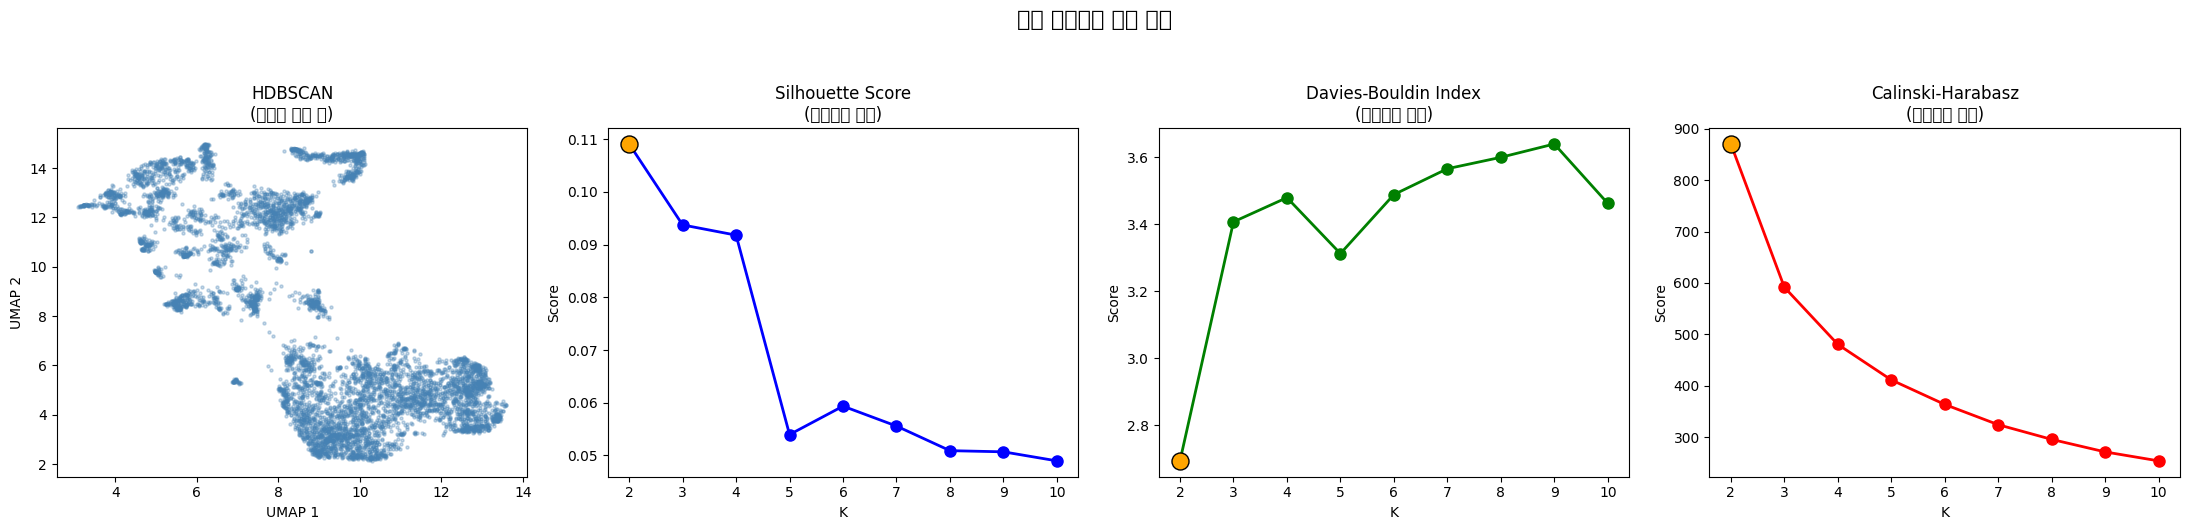

In [25]:
# 4개 지표 시각화
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# (1) HDBSCAN UMAP
axes[0].scatter(embedding_2d_clean[:, 0], embedding_2d_clean[:, 1],
                c='steelblue', alpha=0.3, s=5)
axes[0].set_title('HDBSCAN\n(노이즈 제거 후)', fontsize=12)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# (2) Silhouette
axes[1].plot(K_range, silhouettes, 'bo-', linewidth=2, markersize=8)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].set_title('Silhouette Score\n(높을수록 좋음)', fontsize=12)
axes[1].set_xticks(list(K_range))
peak_idx = np.argmax(silhouettes)
axes[1].scatter([list(K_range)[peak_idx]], [silhouettes[peak_idx]],
                c='orange', s=150, zorder=5, edgecolors='black')

# (3) Davies-Bouldin
axes[2].plot(K_range, davies_bouldin, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')
axes[2].set_title('Davies-Bouldin Index\n(낮을수록 좋음)', fontsize=12)
axes[2].set_xticks(list(K_range))
low_idx = np.argmin(davies_bouldin)
axes[2].scatter([list(K_range)[low_idx]], [davies_bouldin[low_idx]],
                c='orange', s=150, zorder=5, edgecolors='black')

# (4) Calinski-Harabasz
axes[3].plot(K_range, calinski, 'ro-', linewidth=2, markersize=8)
axes[3].set_xlabel('K')
axes[3].set_ylabel('Score')
axes[3].set_title('Calinski-Harabasz\n(높을수록 좋음)', fontsize=12)
axes[3].set_xticks(list(K_range))
ch_peak = np.argmax(calinski)
axes[3].scatter([list(K_range)[ch_peak]], [calinski[ch_peak]],
                c='orange', s=150, zorder=5, edgecolors='black')

plt.suptitle('최적 클러스터 판단 지표', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig("./cluster_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.3 최종 클러스터링

> 위 지표를 종합하여 K를 결정하세요.
> 지표가 서로 다른 K를 가리키면, 해석 가능성을 함께 고려합니다.

In [26]:
# ============================
N_CLUSTERS = 4  # 또는 직접 숫자 입력
# ============================

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, max_iter=300)
df_clean['cluster'] = km_final.fit_predict(embeddings_clean)

print(f"K={N_CLUSTERS} 최종 클러스터링 완료\n")
print("[ 군집별 데이터 건수 ]")
for c, cnt in df_clean['cluster'].value_counts().sort_index().items():
    print(f"  군집 {c}: {cnt:,}건 ({cnt/len(df_clean)*100:.1f}%)")

K=4 최종 클러스터링 완료

[ 군집별 데이터 건수 ]
  군집 0: 1,554건 (22.8%)
  군집 1: 1,630건 (23.9%)
  군집 2: 1,454건 (21.3%)
  군집 3: 2,192건 (32.1%)


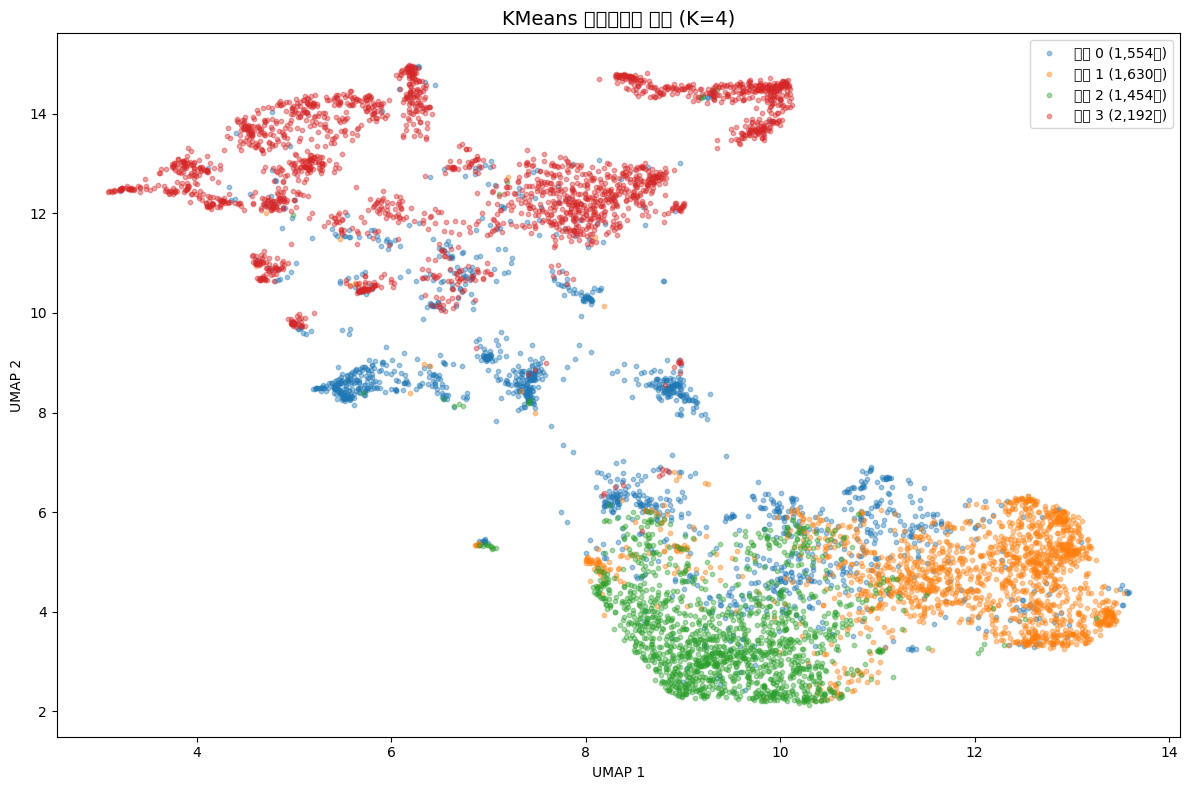

In [27]:
# UMAP 2D 시각화 (최종 군집)
fig, ax = plt.subplots(figsize=(12, 8))

for c in sorted(df_clean['cluster'].unique()):
    mask = df_clean['cluster'] == c
    ax.scatter(embedding_2d_clean[mask, 0], embedding_2d_clean[mask, 1],
               alpha=0.4, s=10, label=f'군집 {c} ({mask.sum():,}건)')

ax.set_title(f'KMeans 클러스터링 결과 (K={N_CLUSTERS})', fontsize=14)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("./cluster_final_umap.png", dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# 저장
df_clean.to_pickle('./embedding_cluster_review.pkl')
print(f"embedding_cluster_review.pkl 저장 완료 ({len(df_clean):,}건)")

embedding_cluster_review.pkl 저장 완료 (6,830건)


## 6. 해석하기 (C-TF-IDF)

> 임베딩으로 클러스터링했지만, **해석은 C-TF-IDF + 원문 확인**으로 합니다.
> 키워드는 힌트, 원문 확인이 Actor 정의의 근거입니다.

### 6.1 군집별 C-TF-IDF 계산

In [29]:
# 각 군집별 문서를 하나로 합치기
all_document = []
for i in sorted(df_clean['cluster'].unique()):
    cluster_tokens = df_clean[df_clean['cluster'] == i]['tagged_review']
    joined = ' '.join([' '.join(tokens) for tokens in cluster_tokens])
    all_document.append(joined)

print(f"군집 수: {len(all_document)}")
for i, doc in enumerate(all_document):
    print(f"  군집 {i}: {len(doc.split()):,} 토큰")

군집 수: 4
  군집 0: 50,573 토큰
  군집 1: 50,908 토큰
  군집 2: 79,180 토큰
  군집 3: 132,735 토큰


In [30]:
df_clean

,title,content,source_file,content_clean,tagged_review,cluster
0,NaN,"제가 쿠쿠정수기 렌탈을 약 6년전에 시작해서 매달 19,900원을 내고 5년 사용후...","네이트판_통합_렌탈,가전구독.csv",제가 쿠쿠정수기 렌탈을 약 6년전에 시작해서 매달 19 900원을 내고 5년 사용후...,"[쿠쿠, 정수기, 렌탈, 시작, 사용, 개인, 소유, 변경, 멤버, 서비스, 필터,...",3
1,NaN,오늘 이걸로 남사친이랑 엄청 싸웠습니다. 요즘 “커피 심부름은 60~70년대 얘기고...,"네이트판_통합_렌탈,가전구독.csv",오늘 이걸로 남사친이랑 엄청 싸웠습니다 요즘 커피 심부름은 60 70년대 얘기고 8...,"[사친, 커피, 심부름, 얘기, 대생, 보이, 현실, 왜곡, 본인, 기억, 편하, ...",2
2,NaN,무엇이든 렌탈을 하기전에 구체적인 계약내용을 친필로 적어 두는 것이 좋습니다. 일...,"네이트판_통합_렌탈,가전구독.csv",무엇이든 렌탈을 하기전에 구체적인 계약내용을 친필로 적어 두는 것이 좋습니다 일단 ...,"[렌탈, 구체, 계약, 내용, 친필, 계약, 무기, 간전, 해약, 경우, 비용, 지...",3
3,NaN,제목대로 어떻게 해야할까요?? 믿어야할까요? 남친 26이고 저는 23입니다. 사귄지...,"네이트판_통합_렌탈,가전구독.csv",제목대로 어떻게 해야할까요 믿어야할까요 남친 26이고 저는 23입니다 사귄지는 2년...,"[제목, 남친, 죄목, 미성년자, 유사, 강간, 남친, 문서, 마시, 여자, 성인,...",2
4,NaN,안녕하세요~ 맨날 눈톡질만하다가 처음으로 글쓰기를 눌러본 91년생을 동경하는 92년...,"네이트판_통합_렌탈,가전구독.csv",안녕하세요 맨날 눈톡질만하다가 처음으로 글쓰기를 눌러본 91년생을 동경하는 92년생...,"[안녕, 처음, 글쓰기, 동경, 남자, 올해, 예체능, 핑계, 겨울, 방학, 보충,...",0
...,...,...,...,...,...,...
6825,생활패턴,"국제성모병원 차민수 교수 ""휴일 이후 평일, 병원 밖 심정지 발생률 높아""",naver_news_생활루틴패턴_최종데이터.csv,국제성모병원 차민수 교수 휴일 이후 평일 병원 밖 심정지 발생률 높아,"[국제, 성모병원, 차민수, 교수, 휴일, 이후, 평일, 병원, 심정지, 발생]",0
6826,생활패턴,[오늘의 운세] 2026년 3월 18일 오늘의 띠별 운세,naver_news_생활루틴패턴_최종데이터.csv,오늘의 운세 2026년 3월 18일 오늘의 띠별 운세,"[오늘, 운세, 오늘, 운세]",0
6827,생활패턴,지방으로 떠났던 청년 셋 중 한 명 '유턴'… 버틴 기간 1년 6개월,naver_news_생활루틴패턴_최종데이터.csv,지방으로 떠났던 청년 셋 중 한 명 유턴 버틴 기간 1년 6개월,"[지방, 청년, 유턴, 기간]",0
6828,생활패턴,"""늑대 잡아달라 했더니 다른 늑대 푼다"" 지금 이 나라에서 벌어지는 일",naver_news_생활루틴패턴_최종데이터.csv,늑대 잡아달라 했더니 다른 늑대 푼다 지금 이 나라에서 벌어지는 일,"[늑대, 잡아달, 늑대, 나라, 벌어지]",0


In [31]:
# C-TF-IDF 계산
ctfidf = TfidfVectorizer()
ctfidf.fit(all_document)
ctfidf_matrix = ctfidf.transform(all_document)
ctfidf_array = ctfidf_matrix.toarray()

vocab = ctfidf.get_feature_names_out()
print(f"단어사전 크기: {len(vocab):,}개")

단어사전 크기: 16,599개


### 6.2 군집별 상위 키워드 확인

In [32]:
cluster_tfidf_df = pd.DataFrame(ctfidf_array, columns=vocab).T
cluster_tfidf_df.columns = [f'군집{i}' for i in range(N_CLUSTERS)]

for col in cluster_tfidf_df.columns:
    temp_df = cluster_tfidf_df[col].sort_values(ascending=False).head(30)
    print(f"\n{'='*50}")
    print(f"[ {col} 상위 30개 키워드 ]")
    print(f"{'='*50}")
    for word, score in temp_df.items():
        if score > 0:
            print(f"  {word:15s} : {score:.4f}")
    temp_df.to_csv(f"./cluster_{col}_embedding.csv", encoding='utf-8-sig')

print(f"\n군집별 키워드 CSV 저장 완료")


[ 군집0 상위 30개 키워드 ]
  렌탈              : 0.5529
  생활              : 0.2329
  사람              : 0.2214
  정도              : 0.2054
  생각              : 0.2018
  스키              : 0.1650
  패턴              : 0.1392
  장비              : 0.1177
  회사              : 0.1142
  가능              : 0.1137
  강습              : 0.1029
  스키장             : 0.1017
  운동              : 0.0922
  고민              : 0.0871
  타이어             : 0.0778
  투표              : 0.0766
  추천              : 0.0766
  루틴              : 0.0766
  업무              : 0.0711
  관리              : 0.0691
  선택              : 0.0681
  카드              : 0.0676
  이용              : 0.0671
  곤지암             : 0.0666
  리프트             : 0.0613
  모르              : 0.0611
  비용              : 0.0606
  상황              : 0.0601
  괜찮              : 0.0586
  영업              : 0.0582

[ 군집1 상위 30개 키워드 ]
  생활              : 0.5059
  운동              : 0.2846
  패턴              : 0.2703
  루틴              : 0.2700
  사람              : 0.2001
  생각           

### 6.3 군집별 원본 문서 확인 (Actor 해석용)

In [33]:
for i in sorted(df_clean['cluster'].unique()):
    cluster_data = df_clean[df_clean['cluster'] == i]
    print(f"\n{'='*60}")
    print(f"군집 {i} ({len(cluster_data):,}건) -- 원문 샘플 5개")
    print(f"{'='*60}")
    samples = cluster_data.sample(min(5, len(cluster_data)), random_state=42)
    for idx, row in samples.iterrows():
        print(f"  [{idx}] {str(row['content'])[:200]}")
        print()


군집 0 (1,554건) -- 원문 샘플 5개
  [6789] 개미 돈 털어 ‘골프 회원권’ 호화생활…국세청, 주가조작 세력 2500억 철퇴

  [818] 당일치기로 스키장 가려는데 리프트랑 장비 렌탈권 같은거 인터넷으로 구매하고 가면 알뜰한 편이겠지..?
렌탈은 스키장 말고 주변에 있는 렌탈샵가고
내가 준비해서 가는게 첨이라... 팁 있음 알려주면 너무 고마웡!!

  [1979] 겨울 시즌 맞아서 스키 타러 다녀오면서 장비 렌탈을 어디서 할까
고민하다가 이용하게 된 곤지암 스키장 렌탈샵이 있습니다
곤지암 쪽은 처음이라 렌탈샵 선택이 꽤 중요했는데 만족도가 높았어요
일단 위치 접근성이 좋았어요. 곤지암역이나 터미널에서 연락드리면
전용 차량으로 곤지암 스키장 렌탈샵에 무료 픽업을 해주시더라구요
이동이 애매했던 입장에서 이 부분이 꽤 편

  [1985] 넥센 기본 타이어 괜찮아서 AU7 렌탈(제휴카드추가할인)로 하려고 하다가 어제 코코 갔더니 넥센 안좋다.. 다다음주 행사들어 간다.. 유혹하네요. ㅋ
벤투스 AIR S 4본 90만원인데 14만원 상품권 주니까 76만원이 되네요.. 고민 되네요. 급차이가 많이 안나면 렌탈이 나을거 같기도 하고.. 선택 장애가.. 확실하게 급차이 나면 벤투스로 가도 되긴하는데

  [3146] 렌탈할라고 하는데
고민이에여

배터리 지속시간 이런거 궁금하네요


군집 1 (1,630건) -- 원문 샘플 5개
  [5118] 6시기상 7시출근 18시 집와서 샤워때리고 낮잠 21시정도 안나서 넷플보면서 소주두세병마심 새벽 한두시에 다시 잠

  [3980] 코로나 바이러스 전이나 지금이나

생활 패턴이 동일한 정도

  [5831] 일찍 자려면 밤새서 저녁까지 버티는 수밖에 없는걸까

  [4196] 근육운동 할 줄모르는데 피티 1시간동안 잘 못버틸거 같아서요 꾸준히 뭘 잘 못하는 타입인데 근육 늘리는데 좋은 운동 있을까요 순발력이나 기초근력은 있어요
인바디 보니까 2년동안 지방은 늘고 근육이 계속 빠지고 있거든요 생활패턴은 같은데

### 6.4 키워드별 원문 필터링 (심층 해석용)

In [ ]:
# ============================
CLUSTER_NUM = 0       # 확인할 군집 번호
KEYWORD = "구독"      # 확인할 키워드
N_SHOW = 10           # 출력할 원문 수
# ============================

cluster_data = df_clean[df_clean['cluster'] == CLUSTER_NUM]
filtered = cluster_data[cluster_data['content'].str.contains(KEYWORD, na=False)]

print(f"군집 {CLUSTER_NUM}에서 '{KEYWORD}' 포함 원문: {len(filtered):,}건")
print("=" * 60)
for idx, row in filtered.head(N_SHOW).iterrows():
    print(f"\n[{idx}] {str(row['content'])[:300]}")
    print("-" * 60)

In [34]:
# 여러 키워드 한꺼번에 확인
CLUSTER_NUM = 0
KEYWORDS = ["가전 구독", "비용"]

cluster_data = df_clean[df_clean['cluster'] == CLUSTER_NUM]
for kw in KEYWORDS:
    filtered = cluster_data[cluster_data['content'].str.contains(kw, na=False)]
    print(f"\n{'='*50}")
    print(f"군집 {CLUSTER_NUM} / 키워드 '{kw}' : {len(filtered):,}건")
    print(f"{'='*50}")
    for idx, row in filtered.head(3).iterrows():
        print(f"  [{idx}] {str(row['content'])[:200]}")
        print()


군집 0 / 키워드 '가전 구독' : 2건
  [1201] 안녕하세요!
저희는 2023년 12월 25일 크리스마스날ㅋㅋㅋ
LG베스트샵 강남본점을 방문해 상담받고 계약했어요.
생긴지 얼마 안 되어 (알고보니 2주년 지났네요)
시설도 너무 좋고 깔끔하더라구요!
(커피 내려주는 로봇도 있어요🤖)
LG베스트샵 강남본점 층별안내
총 5층으로 이루어져 있어요.
최대 규모 전층 가전 매장이라고 하네요 !
쇼룸같은 공간과 빌트인

  [1502] 지금 여신거래차단해놓은상태라
카드발급이 안되거든요
LG가전 구독할까 고민중인데
꼭 제휴카드로 사용해야하나요?


군집 0 / 키워드 '비용' : 84건
  [11] 할머니께서 38년생으로 44년생까지만 렌탈이 된다고해서 손녀인 제가 해드렸죠 근데 박스만 열어보시고 기계 코드연결도 안해보셨고 택배로 받은상품인데 혼자하기 어렵다고 하셔서 렌탈취소하려고 했더니 10월31일 기계받아서 박스만 개봉해보고 11월4일 렌탈취소해보겠다고 했더니 8만원달래요 못들었다고 하니 11월5일 오늘 전화와서 녹취록 들려주는데 어눌한 남자 상담

  [32] 가족 기념일(생일 등)에 선물을 해주려고 얼마 한도내에서 골라달라 하면 저희 가족은 진짜 한도내에서 갖고싶은거 시댁은 한도에 딱맞는걸 항상 골라와요 예를 들어 30만원 한도라고 알려주면 저희가족은 14만원, 18만원 막 이렇게 여유롭게 골라오고 더 비싼거 골라도 된다, 아니면 하나 더 골라라 해도 그거면 된다 하고요 시댁은 29만 9천원, 30만원 진짜 딱

  [39] 본인은 미국여행 출국을 위해 다이슨렌탈을 함. 16박 17일 일정으로 10월19일을 반납하는 날로 지정. 돌아오는 일정에 개인적인 사정으로 인해 반납일 당일 연락을 못하고 반납을 하지 못함. 그후 21일 핸드폰 확인 하고 황당했지만, 연락을 못한 본인 잘못이라 생각해서 사과를 먼저 드리고 반납처리와 추가비용을 서둘러 처리하려고 함. 근데 중간에 배터리 없어



### 6.5 워드클라우드

In [ ]:
from wordcloud import WordCloud
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(6 * N_CLUSTERS, 5))
if N_CLUSTERS == 1:
    axes = [axes]

for i in range(N_CLUSTERS):
    cluster_text = ' '.join([' '.join(tokens) for tokens in df_clean[df_clean['cluster'] == i]['tagged_review']])
    wc = WordCloud(font_path=font_path, width=600, height=400,
                   background_color='white', max_words=50, colormap='viridis').generate(cluster_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'군집 {i} ({len(df_clean[df_clean["cluster"]==i]):,}건)', fontsize=13)
    axes[i].axis('off')

plt.suptitle('군집별 워드클라우드', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("./data/cluster_wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.6 군집별 출처 분포

In [ ]:
if 'source_file' in df_clean.columns:
    cross = pd.crosstab(df_clean['cluster'], df_clean['source_file'])
    display(cross)

    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    fig, ax = plt.subplots(figsize=(14, 6))
    cross_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
    ax.set_xlabel('군집')
    ax.set_ylabel('비율 (%)')
    ax.set_title('군집별 출처 분포')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig("./data/cluster_source_dist.png", dpi=150, bbox_inches='tight')
    plt.show()

## 7. 최종 저장

In [35]:
df_clean.to_pickle('./embedding_cluster_review.pkl')
df_clean.to_csv('./embedding_cluster_review.csv', index=False, encoding='utf-8-sig')

print("=" * 60)
print("Actor 도출 완료")
print("=" * 60)
print(f"  최종 데이터: {len(df_clean):,}건")
print(f"  군집 수: {N_CLUSTERS}개")
print()
for c in sorted(df_clean['cluster'].unique()):
    cnt = len(df_clean[df_clean['cluster'] == c])
    print(f"  군집 {c}: {cnt:,}건 ({cnt/len(df_clean)*100:.1f}%)")

Actor 도출 완료
  최종 데이터: 6,830건
  군집 수: 4개

  군집 0: 1,554건 (22.8%)
  군집 1: 1,630건 (23.9%)
  군집 2: 1,454건 (21.3%)
  군집 3: 2,192건 (32.1%)


---
## 후속 프로세스

### 1단계: Actor 확정
- C-TF-IDF 키워드 + 원본 문서를 함께 보면서 Actor 이름 정의
- 노이즈 군집은 제외

### 2단계: Action 도출 (별도 노트북)
- 각 Actor별 LDA 토픽모델링 → pyLDAvis 시각화

### 3단계: 기회영역 분석 (별도 노트북)
- 만족도(KNU 감성사전) × 중요도(언급량) → Opportunity Score

---
> `cluster_review.pkl`을 다음 노트북에서 불러와서 이어서 작업하세요.
